<a href="https://colab.research.google.com/github/ADA-CompVision/SDP2022-brstcancer/blob/ralili/GAN/gan_models_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import argparse
import os
import numpy as np
import math
import sys

import torchvision.transforms as transforms
from torchvision.utils import save_image

from torch.utils.data import DataLoader, Dataset
from PIL import Image
from torchvision import datasets
from torch.autograd import Variable

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.autograd as autograd

In [3]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

GPU available: True
GPU name: Tesla T4


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "gpu")

In [5]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rumiyyaalili","key":"ab121a81fb536037f0c3dd698d666bb2"}'}

In [6]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d theoviel/rsna-breast-cancer-256-pngs

Dataset URL: https://www.kaggle.com/datasets/theoviel/rsna-breast-cancer-256-pngs
License(s): CC0-1.0
100% 994M/998M [00:27<00:00, 36.9MB/s]
100% 998M/998M [00:28<00:00, 37.3MB/s]


In [8]:
!unzip -qq rsna-breast-cancer-256-pngs

In [9]:
# Create directories
os.makedirs("images", exist_ok=True)

In [12]:
import os

dataset_path = "/content"
extensions = (".png", ".jpg", ".jpeg")

# Count all image files recursively
total_images = 0
for root, _, files in os.walk(dataset_path):
    total_images += sum(file.lower().endswith(extensions) for file in files)

print(f"Total number of images in the dataset: {total_images}")

Total number of images in the dataset: 54706


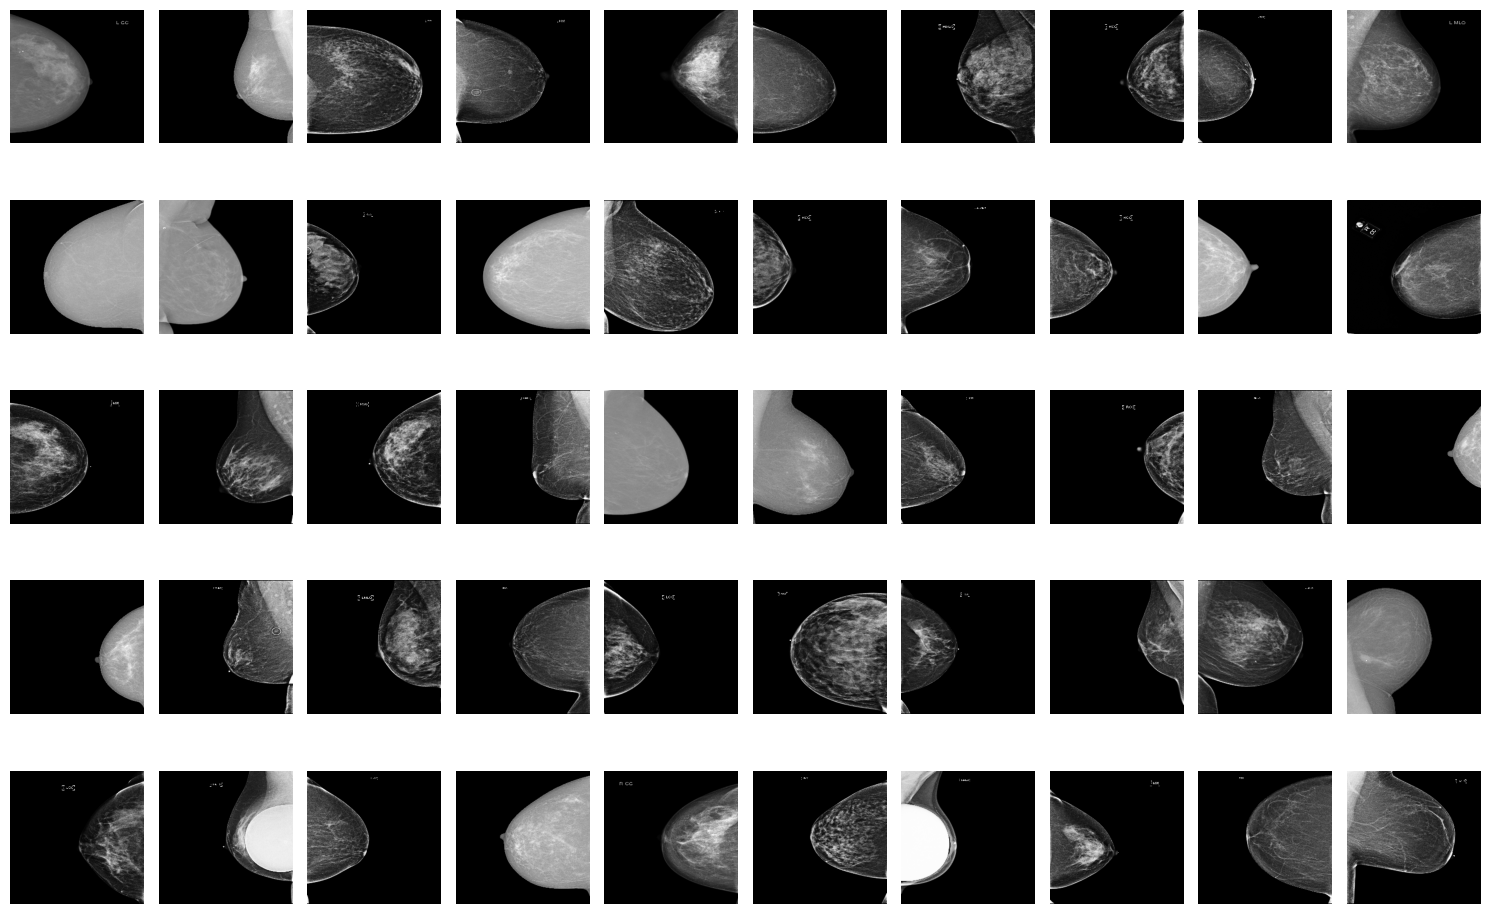

In [13]:
import os
from PIL import Image
import matplotlib.pyplot as plt

dataset_path = "/content"
extensions = (".png", ".jpg", ".jpeg")

# Get the first 50 image file paths
image_files = []
for root, _, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(extensions):
            image_files.append(os.path.join(root, file))
        if len(image_files) >= 50:  # Stop after collecting 50 images
            break
    if len(image_files) >= 50:
        break

# Display the first 50 images
fig, axes = plt.subplots(5, 10, figsize=(15, 10))  # Create a 5x10 grid
axes = axes.flatten()

for img_path, ax in zip(image_files, axes):
    img = Image.open(img_path).convert("L")  # Convert to grayscale
    ax.imshow(img, cmap="gray")  # Display as grayscale
    ax.axis('off')

plt.tight_layout()
plt.show()

In [14]:
import os
from PIL import Image

# Paths
dataset_path = "/content"
aligned_dir = os.path.join(dataset_path, "aligned_images")
os.makedirs(aligned_dir, exist_ok=True)

def classify_breast(image):
    # Convert image to numpy array
    img_array = np.array(image)

    # Compute symmetry
    h, w = img_array.shape[:2]
    left_half = img_array[:, :w // 2]
    right_half = img_array[:, w // 2:]

    # Compute average pixel intensity (or other heuristics) for comparison
    left_mean = np.mean(left_half)
    right_mean = np.mean(right_half)

    # Example heuristic: If left side is brighter, it's a left breast image
    if left_mean > right_mean:
        return "LEFT"
    else:
        return "RIGHT"

In [15]:
# Process images
for img_file in os.listdir(dataset_path):
    if img_file.endswith(".png"):
        img_path = os.path.join(dataset_path, img_file)

        image = Image.open(img_path).convert("L")

        # Classify the image
        label = classify_breast(image)

        # Flip the image if it's a left breast
        if label == "LEFT":
            image = image.transpose(Image.FLIP_LEFT_RIGHT)  # Horizontal flip

        # Save the aligned image
        aligned_path = os.path.join(aligned_dir, img_file)
        image.save(aligned_path)

print(f"Alignment complete. Aligned images are saved in '{aligned_dir}'.")

Alignment complete. Aligned images are saved in '/content/aligned_images'.


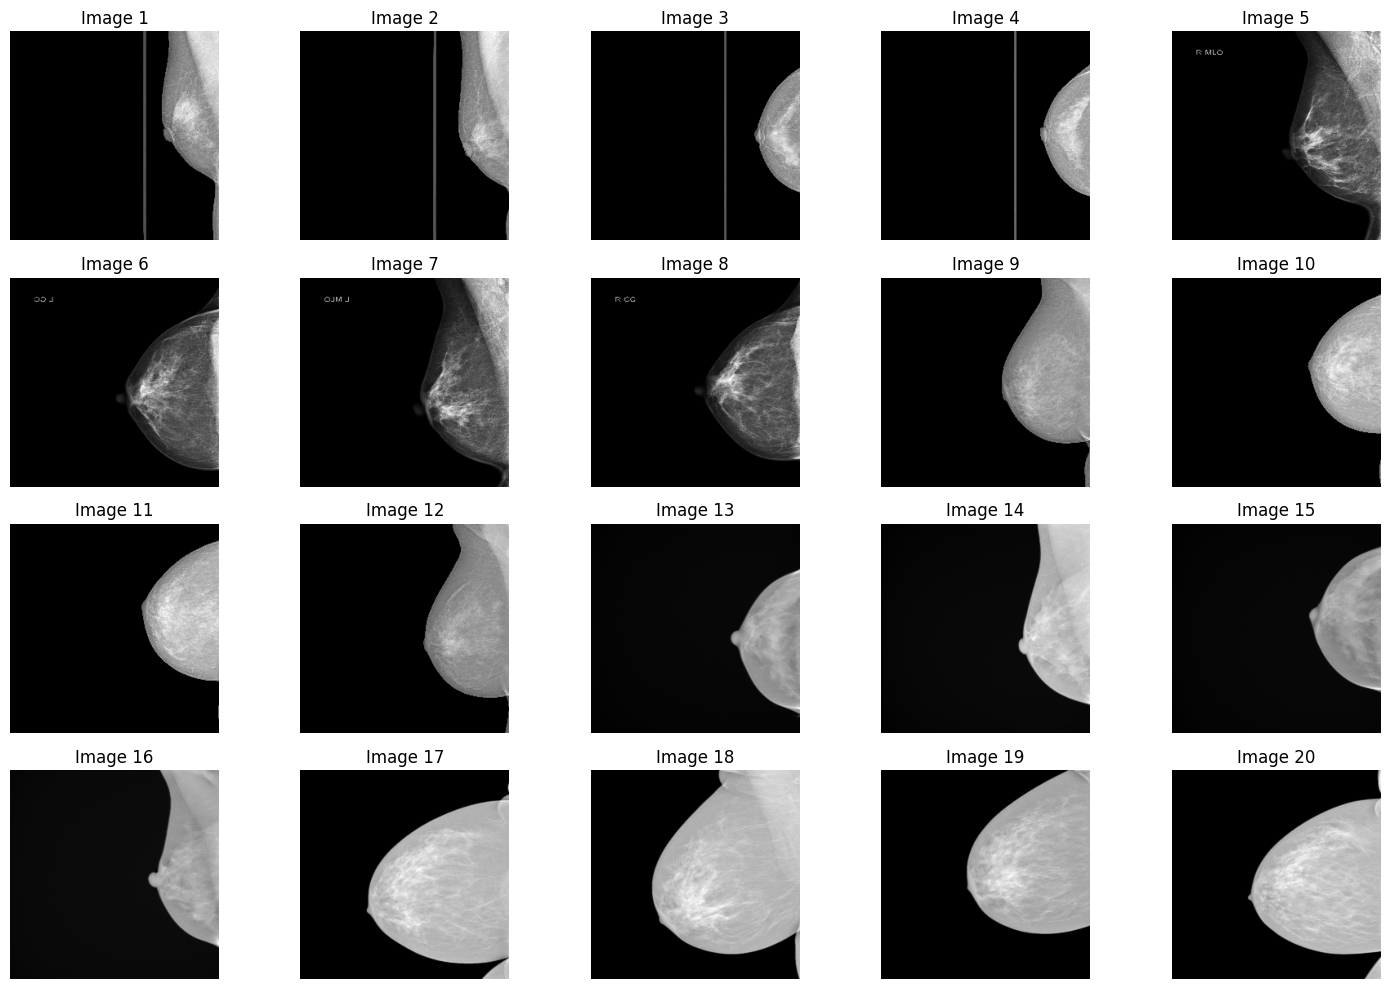

In [16]:
# Directory with aligned images
aligned_dir = "/content/aligned_images"

# Get the first 20 images
image_files = [f for f in os.listdir(aligned_dir) if f.endswith(".png")]
image_files = sorted(image_files)[:20]  # Sort to ensure consistent order

# Plot the images
plt.figure(figsize=(15, 10))
for i, img_file in enumerate(image_files):
    img_path = os.path.join(aligned_dir, img_file)
    image = Image.open(img_path)

    # Display each image in a grid
    plt.subplot(4, 5, i + 1)  # 4 rows, 5 columns for 20 images
    plt.imshow(image, cmap="gray")
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Number of bright, high-contrast images: 12714


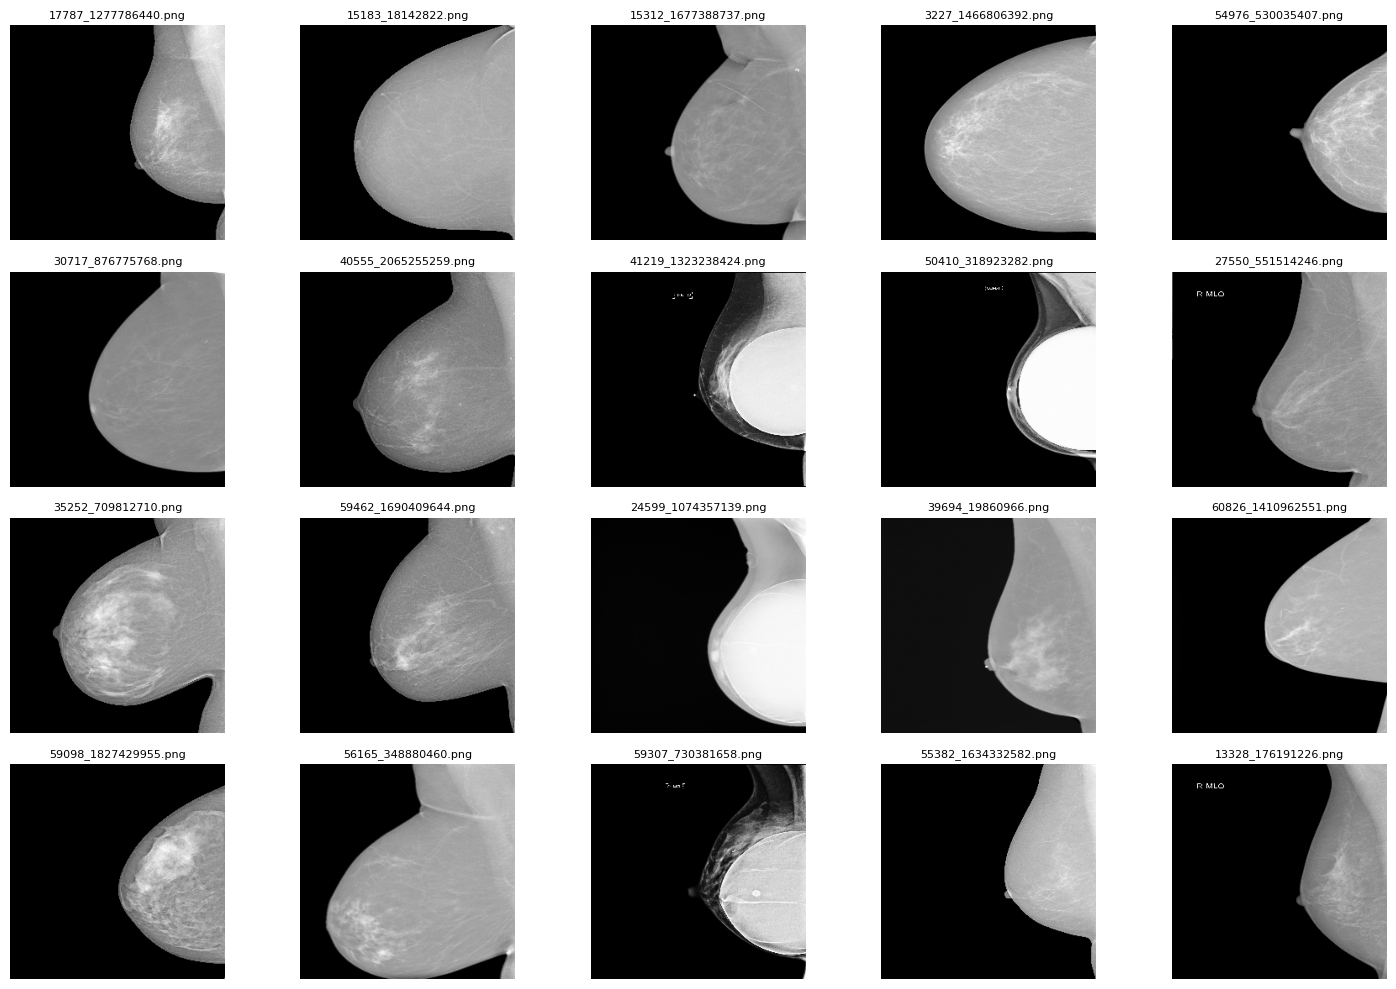

In [17]:
dataset_dir = "/content/aligned_images"

# thresholds for detecting high-contrast and bright images
brightness_threshold = 0.5  # Pixels brighter than this are considered white - increase for very bright regions
region_brightness_ratio = 0.15  # Proportion of image that must be bright to qualify - decrease if missing images with smaller bright areas
contrast_threshold = 0.2  # Minimum contrast difference to identify bright regions - decrease to include images with slightly less contrast

# function to identify high-contrast, bright images
def find_bright_contrast_images(dataset_dir, brightness_threshold, region_brightness_ratio, contrast_threshold):
    bright_images = []
    bright_filenames = []

    for filename in os.listdir(dataset_dir):
        if filename.endswith((".png")):
            # Load image
            img_path = os.path.join(dataset_dir, filename)
            img = Image.open(img_path)

            # Normalize pixel values to [0, 1]
            img_array = np.array(img) / 255.0

            # Calculate overall contrast (difference between max and min pixel intensities)
            contrast = np.max(img_array) - np.min(img_array)

            # Identify bright pixels
            bright_pixels = img_array >= brightness_threshold
            bright_pixel_ratio = np.sum(bright_pixels) / img_array.size

            # Check conditions for bright and high-contrast images
            if contrast > contrast_threshold and bright_pixel_ratio > region_brightness_ratio:
                bright_images.append(img)
                bright_filenames.append(filename)

    return bright_images, bright_filenames

# Identify high-intensity and high-contrast images
bright_images, bright_filenames = find_bright_contrast_images(
    dataset_dir, brightness_threshold, region_brightness_ratio, contrast_threshold
)

# Print the number of bright, high-contrast images
print(f"Number of bright, high-contrast images: {len(bright_images)}")

# Display the first 20 bright images
num_to_display = min(20, len(bright_images))
plt.figure(figsize=(15, 10))
for i in range(num_to_display):
    plt.subplot(4, 5, i + 1)  # 4 rows x 5 columns
    plt.imshow(bright_images[i], cmap="gray")
    plt.title(bright_filenames[i], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
# Remove identified images from the dataset directory
for filename in bright_filenames:
    img_path = os.path.join(dataset_dir, filename)
    try:
        os.remove(img_path)  # Delete the file
        if random.randint(0,300) == 123:
          print(f"Deleted {filename}")
    except Exception as e:
        print(f"Error deleting {filename}: {e}")

# Print the total number of images remaining in the directory
remaining_images = [filename for filename in os.listdir(dataset_dir) if filename.endswith((".png"))]
print(f"Total number of images remaining: {len(remaining_images)}")

Streaming output truncated to the last 5000 lines.
Deleted 52394_628519936.png
Deleted 55376_319295121.png
Deleted 53914_239791638.png
Deleted 34121_1395663574.png
Deleted 55076_834128581.png
Deleted 54552_2067071793.png
Deleted 50955_1920341118.png
Deleted 9228_1603963186.png
Deleted 54420_1162874067.png
Deleted 62221_937507255.png
Deleted 43843_623907172.png
Deleted 38838_328130212.png
Deleted 25694_963461444.png
Deleted 44186_1773037942.png
Deleted 57791_345992349.png
Deleted 23054_845868586.png
Deleted 61504_1306047915.png
Deleted 17802_67880264.png
Deleted 53835_1455773127.png
Deleted 48566_548879863.png
Deleted 57784_1292437630.png
Deleted 65197_1007838987.png
Deleted 33643_1861926679.png
Deleted 20578_1615837879.png
Deleted 48260_1897749837.png
Deleted 31293_1061367090.png
Deleted 30695_2057201810.png
Deleted 26585_321500709.png
Deleted 62986_1545852226.png
Deleted 55116_772483995.png
Deleted 11763_581392058.png
Deleted 62159_1593001230.png
Deleted 12133_1893666394.png
Deleted 4

In [40]:
# Set parameters
n_epochs = 50  # Number of epochs of training
batch_size = 64  # Size of the batches
lr = 0.0002  # Adam: learning rate
b1 = 0.5  # Adam: decay of first-order momentum of gradient
b2 = 0.999  # Adam: decay of second-order momentum of gradient
latent_dim = 100  # Dimensionality of the latent space
img_size = 256  # Size of each image dimension
channels = 1  # Number of image channels (grayscale)
n_critic = 32  # Number of training steps for discriminator per iteration
clip_value = 0.01  # Lower and upper clip values for discriminator weights
sample_interval = 400  # Interval between image samples
lambda_gp = 10.0 # Define the gradient penalty weight

In [41]:
img_shape = (channels, img_size, img_size)
cuda = True if torch.cuda.is_available() else False

In [42]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, latent_dim, img_shape):
        super(Generator, self).__init__()
        self.img_shape = img_shape
        channels, img_size, _ = img_shape  # Should be (1, 256, 256)

        # Define initial size (downscaled version of the target)
        self.init_size = img_size // 32  # Start with 8x8 feature maps (256/32 = 8)
        self.fc = nn.Linear(latent_dim, 256 * self.init_size * self.init_size)

        self.model = nn.Sequential(
            nn.BatchNorm2d(256),
            nn.Upsample(scale_factor=2),  # 8 → 16
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2),  # 16 → 32
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2),  # 32 → 64
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2),  # 64 → 128
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Upsample(scale_factor=2),  # 128 → 256
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, channels, kernel_size=3, stride=1, padding=1),
            nn.Tanh(),  # Output in range [-1,1]
            )

    def forward(self, z):
        out = self.fc(z)
        out = out.view(out.shape[0], 256, self.init_size, self.init_size)  # Reshape to feature map
        img = self.model(out)
        return img

img_shape = (1, 256, 256)  # Adjusted for 256x256 output
generator = Generator(latent_dim, img_shape)

z = torch.randn(1, latent_dim)  # Generate a random latent vector
output = generator(z)
print("Generated image shape:", output.shape)  # Expected: torch.Size([1, 1, 256, 256])

Generated image shape: torch.Size([1, 1, 256, 256])


In [43]:
import torch
import torch.nn as nn

class Discriminator(nn.Module):
    def __init__(self, img_shape):
        super(Discriminator, self).__init__()
        channels, img_size, _ = img_shape  # Should be (1, 256, 256)

        self.model = nn.Sequential(
            # Conv1: Reduce size from 256 → 256
            nn.Conv2d(channels, 64, kernel_size=3, stride=1, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # Conv1: Reduce size from 256 → 128
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),

            # Conv2: 128 → 64
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # Conv3: 64 → 32
            nn.Conv2d(64, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # Conv4: 32 → 16
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # Conv5: 16 → 8
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            # Flatten for final classification
            nn.Flatten(),

            # Fully connected layers
            nn.Linear(256 * (img_size // 32) * (img_size // 32), 128),  # 8x8 feature map
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 1),  # Output a single value (real/fake)
        )

    def forward(self, img):
        validity = self.model(img)
        return validity

img_shape = (1, 256, 256)
discriminator = Discriminator(img_shape)

test_img = torch.randn(1, *img_shape)  # Generate a random 256x256 image
output = discriminator(test_img)
print("Discriminator output shape:", output.shape)  # Expected: torch.Size([1, 1])

Discriminator output shape: torch.Size([1, 1])


In [44]:
# Directory of the dataset
dataset_dir = "/content/aligned_images"

# Custom Dataset Class to load images
class CustomImageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.png')]  # Filter jpg files

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_name).convert('L')  # Open image and convert to Grayscale (1 channel)

        if self.transform:
            image = self.transform(image)

        return image

# Image transformation pipeline
transform = transforms.Compose([
    transforms.Resize(img_size),  # Resize to the target image size
    transforms.ToTensor(),  # Convert the image to tensor
    transforms.Normalize([0.5], [0.5])  # Normalize grayscale images to [-1, 1]
])

# Create DataLoader
dataset = CustomImageDataset(root_dir=dataset_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Check the first batch of images
for batch in dataloader:
    print(batch.shape)  # Should output (batch_size, 1, 256, 256) for Grayscale images
    break

torch.Size([64, 1, 256, 256])


In [45]:
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch

def generate_and_display_images(generator, num_images=25, latent_dim=100, nrow=5, device="cuda"):
    """
    Generate and display images using the trained generator.

    Args:
        generator (nn.Module): The trained generator model.
        num_images (int): Number of images to generate.
        latent_dim (int): Dimensionality of the latent space.
        nrow (int): Number of images per row in the grid.
        device (str): Device to perform computations on ("cuda" or "cpu").
    """
    generator.eval()  # Set generator to evaluation mode
    with torch.no_grad():  # No need to compute gradients
        # Generate latent vectors
        z = torch.randn(num_images, latent_dim).to(device)
        # Generate images
        generated_images = generator(z)

        # Debug: Print shape of generated images
        print("Generated images shape:", generated_images.shape)

        # Remove any extra dimensions if necessary
        if generated_images.dim() == 5:  # Check if there's an extra dimension
            generated_images = generated_images.squeeze(2)

        # Normalize and move to CPU for display
        generated_images = generated_images.cpu()

        # Display images using a grid
        grid = make_grid(generated_images, nrow=nrow, normalize=True)
        plt.figure(figsize=(10, 10))
        plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
        plt.axis("off")
        plt.show()

Generated images shape: torch.Size([7, 1, 256, 256])


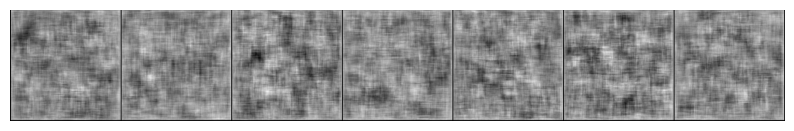

[Epoch 0/50] [Batch 0/657] [D loss: 23.149525] [G loss: 1.221385]
[Epoch 0/50] [Batch 32/657] [D loss: -233.861084] [G loss: 104.232475]
[Epoch 0/50] [Batch 64/657] [D loss: -272.527100] [G loss: 119.904816]
[Epoch 0/50] [Batch 96/657] [D loss: -599.044189] [G loss: 269.675354]
[Epoch 0/50] [Batch 128/657] [D loss: -1307.127563] [G loss: 569.361694]
[Epoch 0/50] [Batch 160/657] [D loss: -1427.689331] [G loss: 616.022583]
[Epoch 0/50] [Batch 192/657] [D loss: -1897.886719] [G loss: 856.243164]
[Epoch 0/50] [Batch 224/657] [D loss: -3067.257080] [G loss: 1367.833984]
[Epoch 0/50] [Batch 256/657] [D loss: -3342.035645] [G loss: 1473.269043]
[Epoch 0/50] [Batch 288/657] [D loss: -3976.667969] [G loss: 1769.406006]
[Epoch 0/50] [Batch 320/657] [D loss: -5693.105469] [G loss: 2513.538086]
[Epoch 0/50] [Batch 352/657] [D loss: -6211.418457] [G loss: 2723.384521]
[Epoch 0/50] [Batch 384/657] [D loss: -6867.373047] [G loss: 3030.241943]
[Epoch 0/50] [Batch 416/657] [D loss: -9009.994141] [G los

KeyboardInterrupt: 

In [46]:
import torch
from torch.autograd import Variable
import numpy as np

checkpoint_interval = 10

# Set the device to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Image shape and model setup
img_shape = (1, img_size, img_size)

# Instantiate models and move them to the GPU
generator = Generator(latent_dim=latent_dim, img_shape=img_shape).to(device)
discriminator = Discriminator(img_shape=img_shape).to(device)

# Define optimizers
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(b1, b2))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))

# Learning Rate Scheduler (Cosine Annealing)
scheduler_G = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_G, T_max=n_epochs)
scheduler_D = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D, T_max=n_epochs)

# Gradient penalty function
def compute_gradient_penalty(D, real_samples, fake_samples):
    """Calculates the gradient penalty loss for WGAN GP"""
    alpha = torch.tensor(np.random.random((real_samples.size(0), 1, 1, 1)), dtype=torch.float32, device=device)
    interpolates = (alpha * real_samples + ((1 - alpha) * fake_samples)).requires_grad_(True)
    d_interpolates = D(interpolates)

    fake = Variable(torch.ones(real_samples.shape[0], 1, dtype=torch.float32, device=device), requires_grad=False)

    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=fake,
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

# ----------
#  Training
# ----------

batches_done = 0
d_loss_val = 0
g_loss_val = 0

for epoch in range(1,n_epochs+1):
    if epoch % 5 == 0:
        generate_and_display_images(generator, num_images=7, latent_dim=latent_dim, nrow=7, device=device)
    for i, imgs in enumerate(dataloader):

        # Ensure the tensors are float32 and move to device
        real_imgs = Variable(imgs.type(torch.float32).to(device))

        # ---------------------
        #  Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        # Sample noise as generator input
        z = Variable(torch.tensor(np.random.normal(0, 1, (imgs.shape[0], latent_dim)), dtype=torch.float32).to(device))

        # Generate a batch of images
        fake_imgs = generator(z)

        # Reshape fake images to match the shape of real images
        fake_imgs = fake_imgs.view(fake_imgs.size(0), 1, img_size, img_size)

        # Real images
        real_validity = discriminator(real_imgs)
        # Fake images
        fake_validity = discriminator(fake_imgs)
        # Gradient penalty
        gradient_penalty = compute_gradient_penalty(discriminator, real_imgs.data, fake_imgs.data)
        # Adversarial loss
        d_loss = -torch.mean(real_validity) + torch.mean(fake_validity) + lambda_gp * gradient_penalty

        # Apply gradient clipping
        torch.nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=1.0)

        # Backprop and optimizer step
        d_loss.backward()
        d_loss_val = d_loss.item()

        optimizer_D.step()

        optimizer_G.zero_grad()

        # Train the generator every n_critic steps
        if i % n_critic == 0:

            # -----------------
            #  Train Generator
            # -----------------

            # Generate a batch of images
            fake_imgs = generator(z)

            # Reshape fake images to match the shape of real images
            fake_imgs = fake_imgs.view(fake_imgs.size(0), 1, img_size, img_size)

            # Loss measures generator's ability to fool the discriminator
            # Train on fake images
            fake_validity = discriminator(fake_imgs)
            g_loss = -torch.mean(fake_validity)

            # Apply gradient clipping
            torch.nn.utils.clip_grad_norm_(generator.parameters(), max_norm=1.0)

            # Backprop and optimizer step
            g_loss.backward()
            optimizer_G.step()

            # print(
            #     "[Epoch %d/%d] [Batch %d/%d] [D loss: %f] [G loss: %f]"
            #     % (epoch, n_epochs, i, len(dataloader), d_loss.item(), g_loss.item())
            # )
            g_loss_val = g_loss.item()

            if batches_done % sample_interval == 0:
                save_image(fake_imgs.data[:25], "images/%d.png" % batches_done, nrow=5, normalize=True)

            batches_done += 1

        # Step the schedulers (learning rate adjustment)
        scheduler_G.step()
        scheduler_D.step()

        # Optional: Save checkpoint of model periodically (every few epochs)
        if epoch % checkpoint_interval == 0 and i == len(dataloader) - 1:
            torch.save(generator.state_dict(), 'generator_checkpoint.pth')
            torch.save(discriminator.state_dict(), 'discriminator_checkpoint.pth')

    print("[Epoch %d/%d] [D loss: %f] [G loss: %f]"
             % (epoch, n_epochs, d_loss_val, g_loss_val)
            )